

## Modelos de *Aprendizaje supervisado* (Modelos de regresión y clasificación)




# Importación dataset

In [14]:
from sklearn.datasets import fetch_openml
dfr = fetch_openml(data_id=189, parser='auto') # Escriba en este espacio el id correspondientes del dataset de regresión del item escogido
dfc = fetch_openml(data_id=1479, parser='auto') # Escriba en este espacio el id correspondientes del dataset de clasificasión del item escogido

In [15]:
dfr= dfr.frame
dfc= dfc.frame

## Contextualización Dataset.

Detalle de ambos dataset la información siguiente:

## Dataset Regresión
* Contexto del dataset: El dataset trata sobre la cinemática directa de un brazo robótico, es decir, se busca predecir la posición final del brazo a partir de los ángulos de sus diferentes articulaciones. De esta manera, el objetivo es identificar la relación entre los movimientos de las articulaciones y la posición que alcanza el brazo.
* Tamaño: 8192 filas × 9 columnas.
* Variable objetivo: y.
* Variables asociadas: theta1, theta2, theta3, theta4, theta5, theta6, theta7, theta8.


## Dataset Clasificación
* Contexto del dataset: El dataset Hill-Valley contiene registros que representan curvas formadas por 100 puntos en un gráfico 2D. El objetivo es clasificar cada curva según su forma, determinando si corresponde a un valle (0) o a una colina (1). Al representar los 100 valores en el orden en que aparecen, se puede observar la forma de la curva. Por esta razón, el modelo debe identificar el patrón general formado por los puntos para realizar correctamente la clasificación.
* Tamaño: 1211 filas × 101 columnas.
* Variable objetivo: Class
* Variables asociadas: V1 hasta V100.

#  Análisis cuantitativo y cualitativo.

## Diagramas de dispersion y respectivo análisis

### Regresión

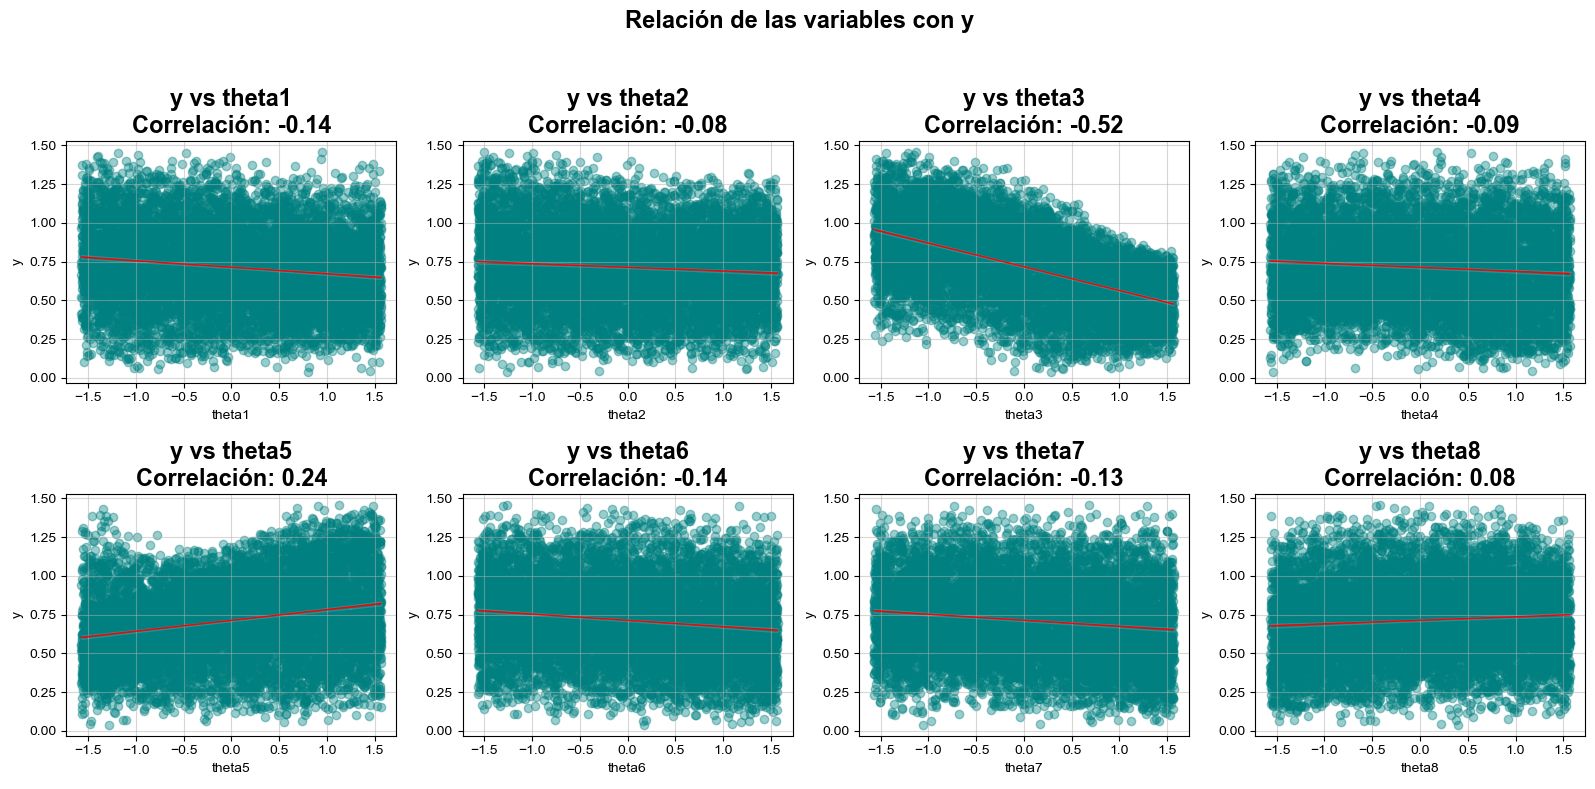

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, numpy as np, pandas as pd
from matplotlib.colors import LinearSegmentedColormap

cmap_personalizado = LinearSegmentedColormap.from_list(
    "purple_teal",
    ["purple", "teal"]
)



variables= ['theta1', 'theta2', 'theta3', 'theta4', 'theta5', 'theta6', 'theta7', 'theta8' ]

fig, axes = plt.subplots(2,4, figsize=(16,8))


for ax, variable in zip(axes.flat, variables):
    correlacion = dfr[variable].corr(dfr['y'])
    
    sns.regplot(x = variable, y ='y', data=dfr, ax=ax, color='teal',  scatter_kws={'alpha': 0.4}, line_kws={"color": "red","linewidth": 1})
    ax.set_title(
        f'y vs {variable}\nCorrelación: {correlacion:.2f}',
        fontweight='bold', fontsize=17)
    ax.set_xlabel(variable)
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.5)

    fig.suptitle('Relación de las variables con y', fontsize=17, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
plt.show()


Se observa en la gráfica que theta3 es la variable que tiene mayor correlación con la variable objetivo, con una correlación negativa moderada de -0.52. Esto quiere decir que, cuando theta3 aumenta, la variable objetivo (y) tiende a disminuir. Sin embargo, los datos presentan bastante dispersión, por lo que la relación no es perfecta.

La segunda variable con mayor correlación es theta5, con una correlación positiva de 0.24, lo que indica una relación positiva, aunque más débil que la de theta3.

### Clasificación

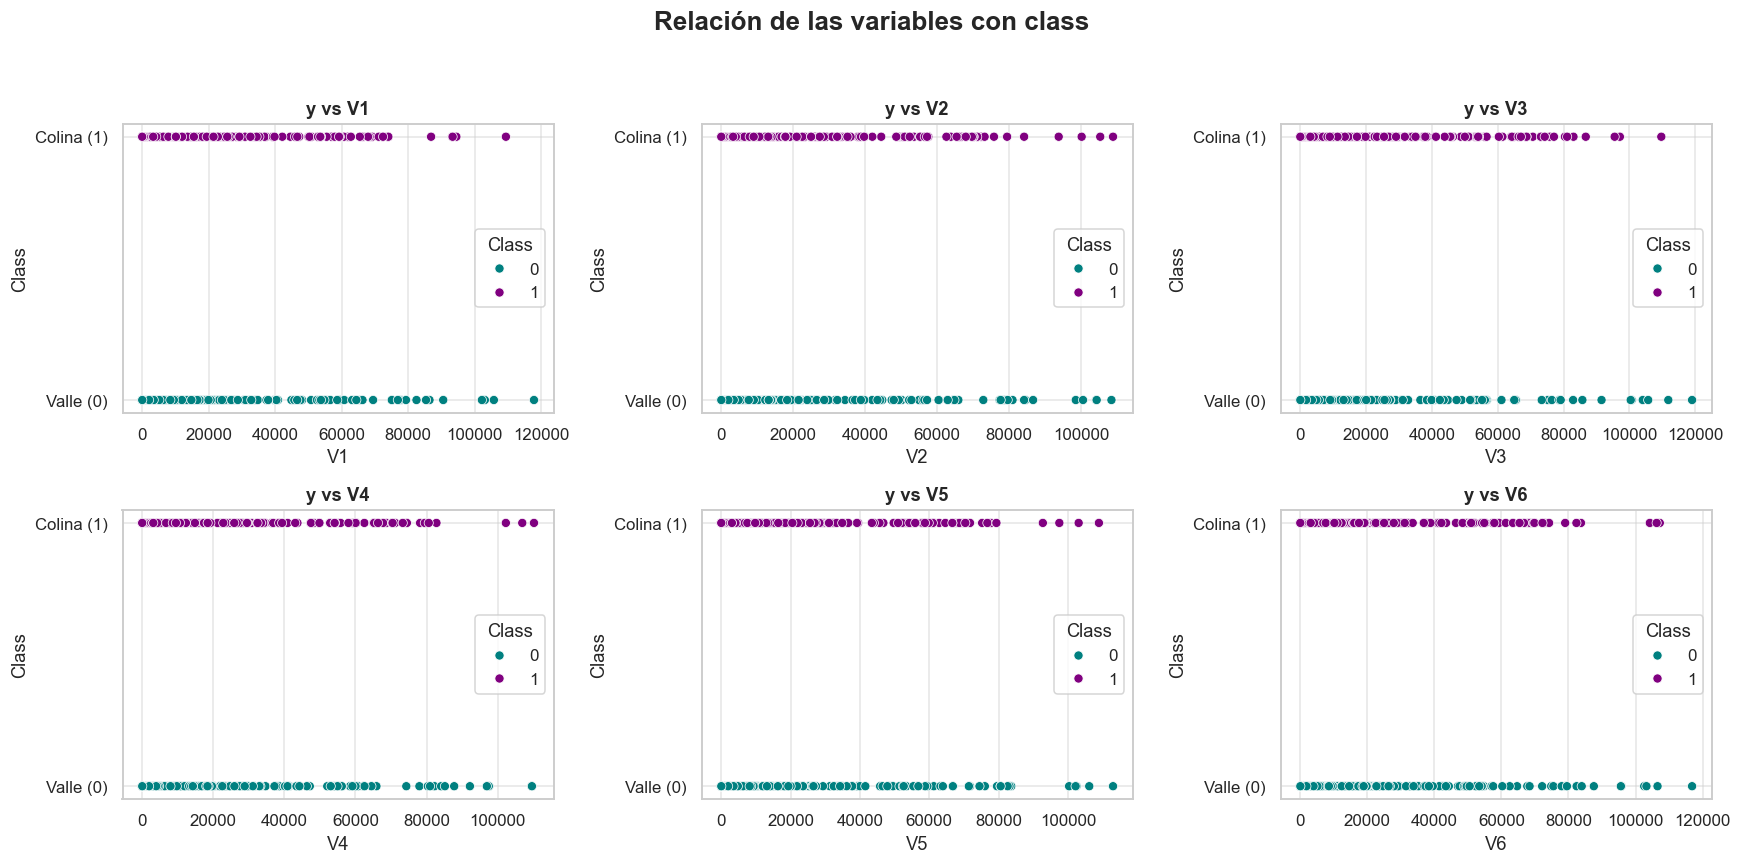

In [17]:
dfc['Class'] = dfc['Class'].astype(int)

variablesc= ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', ]

fig, axes = plt.subplots(2,3, figsize=(16,8))

for ax, variable in zip(axes.flat, variablesc):
    sns.scatterplot(x = variable, y ='Class', data=dfc, ax=ax, hue='Class', palette={0: 'teal', 1: 'purple'})
    ax.set_title(f'y vs {variable}', fontweight='bold')
    ax.set_xlabel(variable)
    ax.set_ylabel('Class')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Valle (0)', 'Colina (1)'])
    ax.grid(True, alpha=0.5)

    fig.suptitle('Relación de las variables con class', fontsize=17, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
#plt.tight_layout()
plt.show()


Este diagrama de dispersión muestra la relación entre algunas de las variables predictoras V1 a V6 y la variable objetivo Class. La clase 0 corresponde a Valle y la clase 1 a Colina. Cada punto representa una observación y su posición en el eje X indica el valor de la variable correspondiente. Se observa que las dos clases presentan valores bastante dispersos y rangos similares, por lo que no se aprecia una separación clara entre Valle y Colina ni una relación clara con la variable objetivo al analizar estas variables de manera individual.

## Diagramas de barras y respectivo análisis

### Regresión

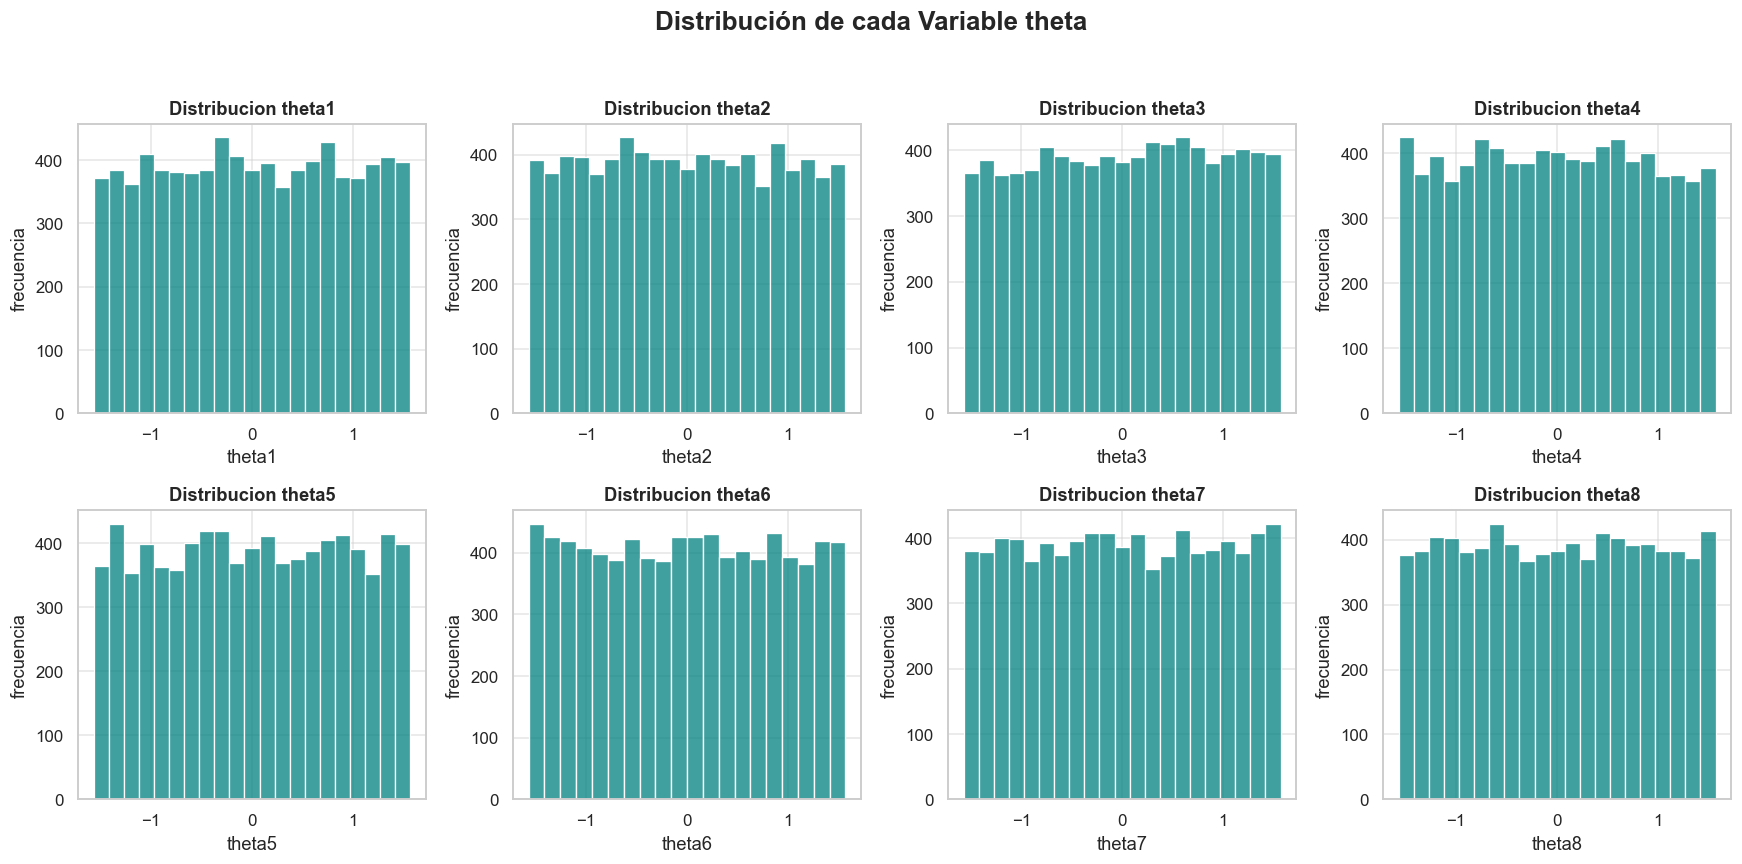

In [18]:

fig, axes = plt.subplots(2,4, figsize=(16,8))


for ax, variable in zip(axes.flat, variables):
    sns.histplot(x = variable, data=dfr, ax=ax, color='teal' )
    ax.set_title(f'Distribucion {variable}', fontweight='bold')
    ax.set_xlabel(variable)
    ax.set_ylabel('frecuencia')
    ax.grid(True, alpha=0.5)

    fig.suptitle('Distribución de cada Variable theta', fontsize=17, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
#plt.tight_layout()
plt.show()


El gráfico de histogramas muestra que las variables presentan una distribución aproximadamente uniforme, con valores entre -1.6 y 1.6. No se observan sesgos muy marcados ni concentraciones excesivas en determinados valores. Esto sugiere que los datos están distribuidos de manera relativamente homogénea, lo que puede facilitar el entrenamiento del modelo.

### Clasificación

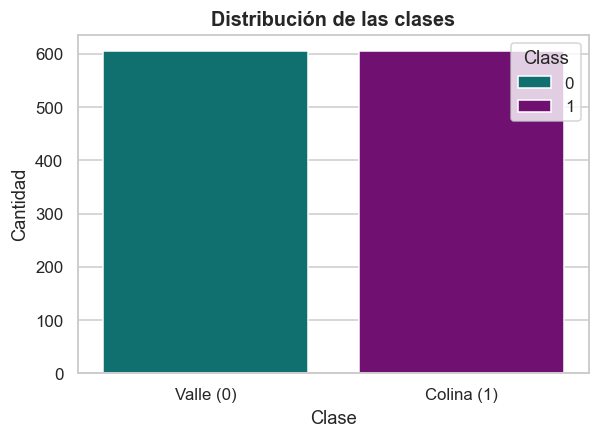

In [19]:

plt.figure(figsize = (6,4))
sns.countplot(x = 'Class', data = dfc, hue="Class", palette=["teal","purple"])
plt.title('Distribución de las clases', fontsize=13, fontweight='bold')
plt.xlabel('Clase')
plt.ylabel('Cantidad')

plt.xticks([0, 1], ['Valle (0)', 'Colina (1)'])

plt.show()

El gráfico de barras muestra la cantidad de datos que hay en cada clase del dataset. Se puede observar que la Clase 0 y la Clase 1 tienen una cantidad de registros muy similar, por lo que se puede decir que el dataset está balanceado. Esto es positivo para el entrenamiento del modelo, ya que ninguna de las dos clases tiene una cantidad mucho mayor de datos que la otra. Sin embargo, esto no significa que el modelo vaya a clasificar las dos clases con la misma precisión, por lo que también es importante revisar las métricas.

## Boxplots y respectivo análisis

### Regresión

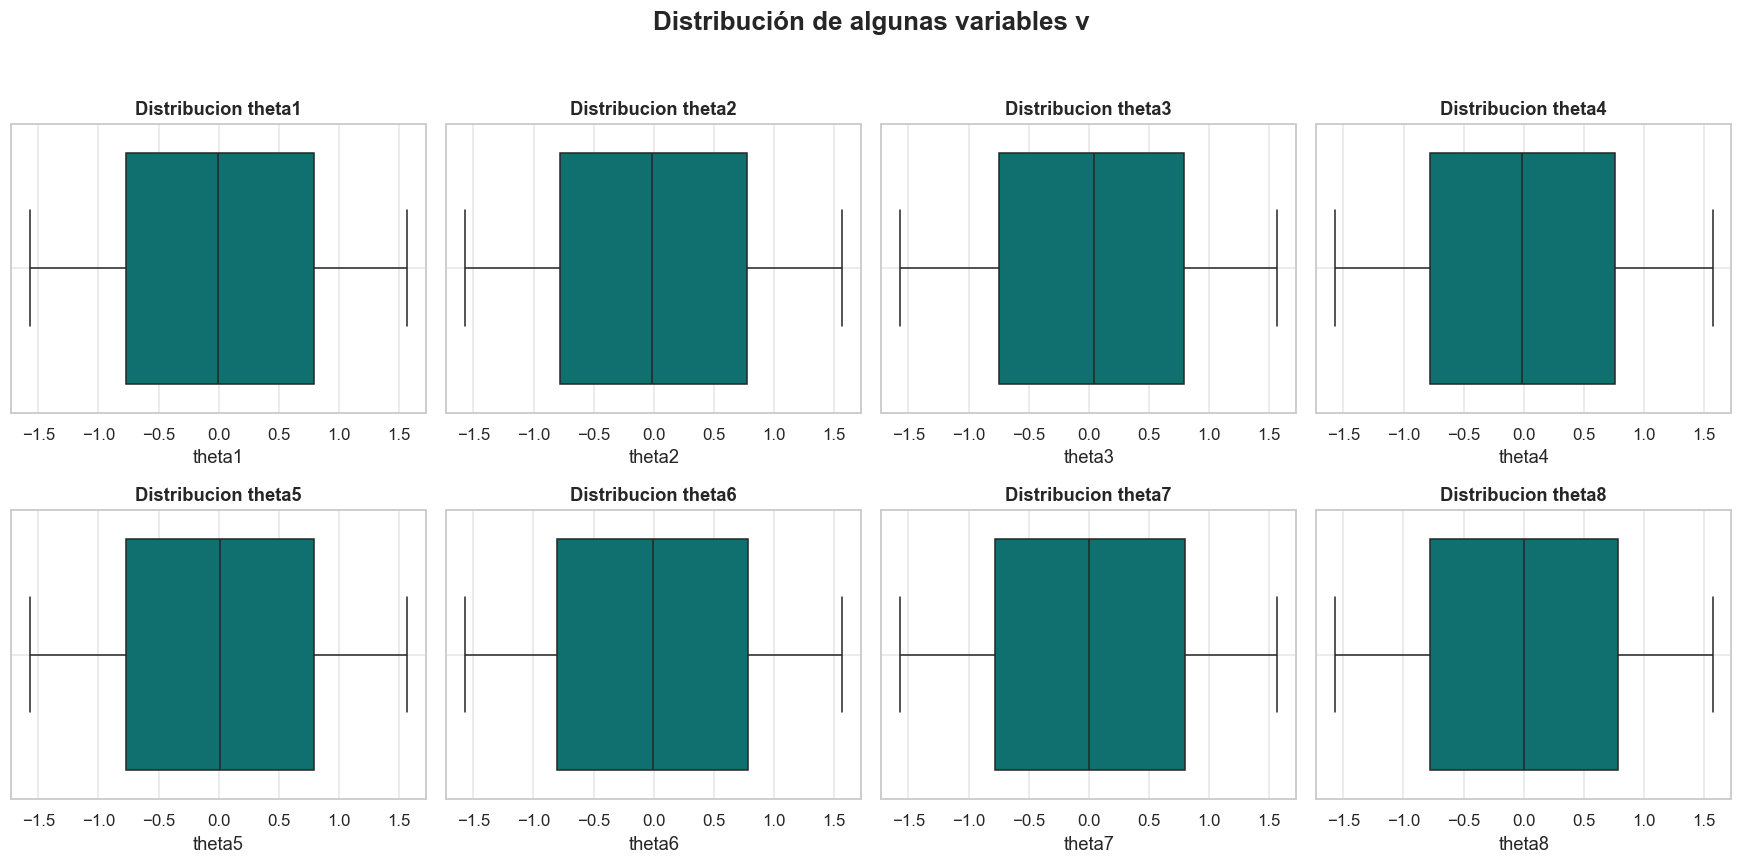

In [20]:
fig, axes = plt.subplots(2,4, figsize=(16,8))


for ax, variable in zip(axes.flat, variables):
    sns.boxplot(x = variable, data=dfr, ax=ax, color='teal' )
    ax.set_title(f'Distribucion {variable}', fontweight='bold')
    ax.set_xlabel(variable)
 
    ax.grid(True, alpha=0.5)

    fig.suptitle('Distribución de algunas variables v', fontsize=17, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
#plt.tight_layout()
plt.show()

Los diagramas de cajas muestran que las ocho variables theta1 a theta8 tienen distribuciones similares, con valores en la mediana cercanos a 0 y sin valores atípicos. Esto indica que las variables predictoras están en escalas similares entre sí.

### Clasificación

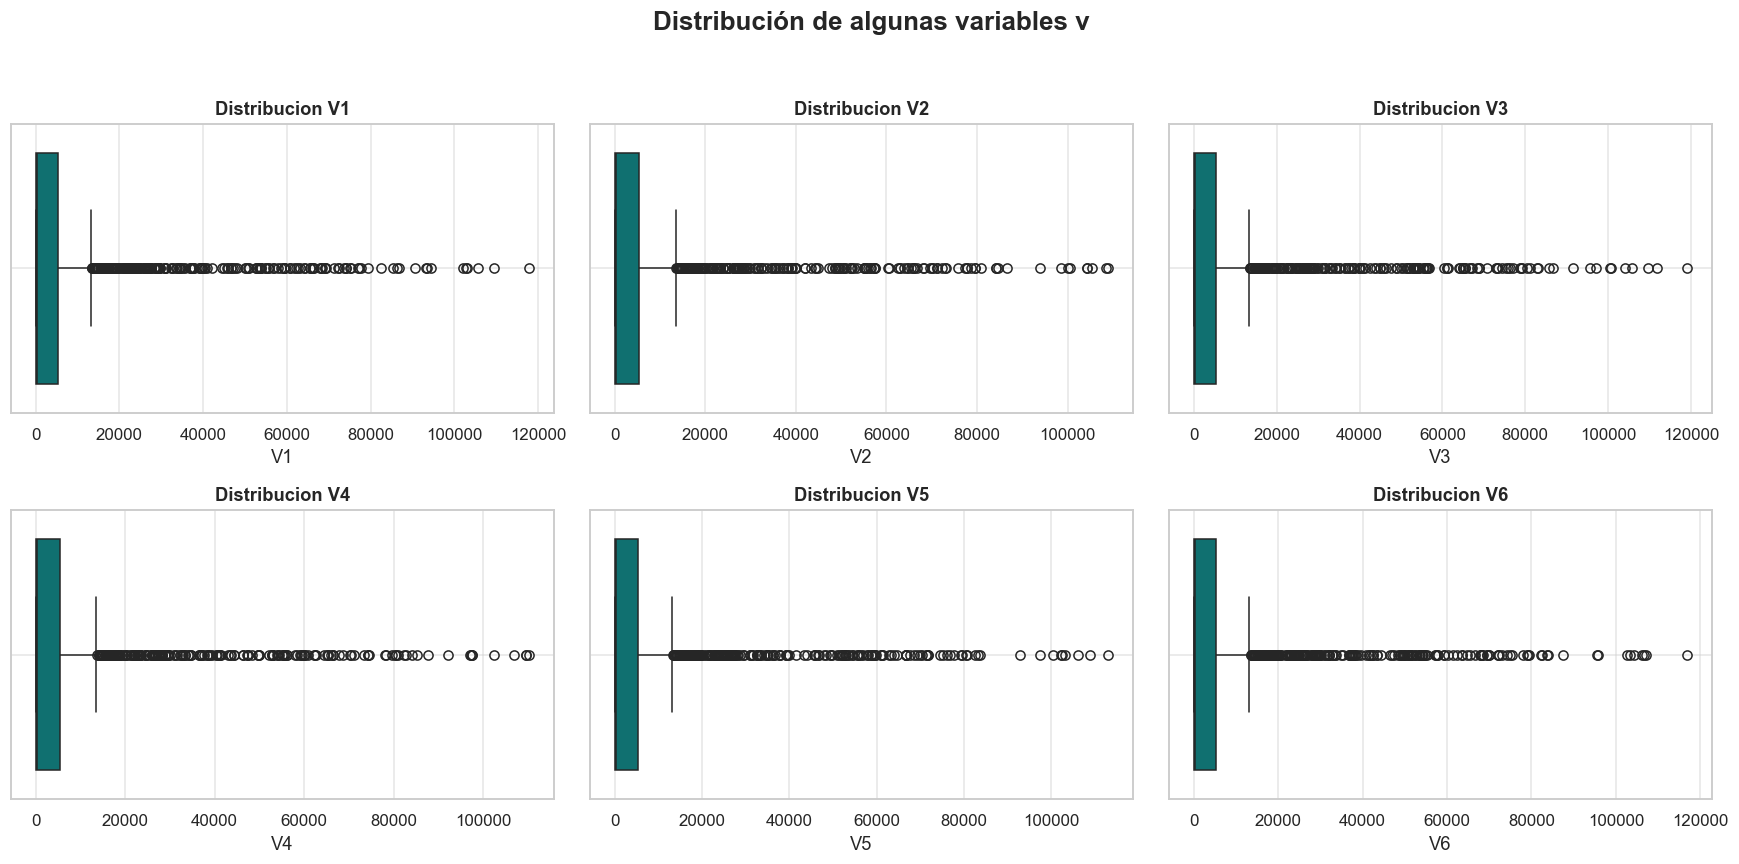

In [41]:
fig, axes = plt.subplots(2,3, figsize=(16,8))


for ax, variable in zip(axes.flat, variablesc):
    sns.boxplot(x = variable, data=dfc, ax=ax, color='teal' )
    ax.set_title(f'Distribucion {variable}', fontweight='bold')
    ax.set_xlabel(variable)
 
    ax.grid(True, alpha=0.5)

    fig.suptitle('Distribución de algunas variables v', fontsize=17, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
#plt.tight_layout()
plt.show()


Los diagramas de caja muestran la distribución de algunas de las variables predictoras la mayoría de los datos concentrados en valores bajos y varios valores alejados del resto de los datos. Estos posibles valores atípicos aparecen en todas las variables, aunque en diferentes cantidades, por lo que se observa en los gráficos, sería conveniente realizar un escalado de los datos, ya que las variables presentan rangos de valores muy diferentes y algunos valores atipicos bastante elevados. El escalado permitiría que las variables tengan una escala más comparable y evitaría que aquellas con valores numéricamente más grandes tengan mayor influencia en modelos sensibles a la escala.

## Matriz de correlaciones (Heatmap) y respectivo análisis

### Regresión

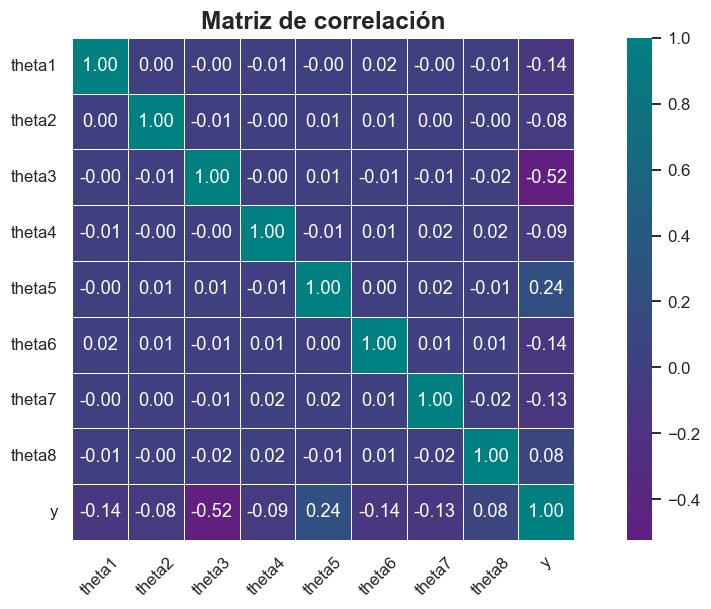

In [22]:

corr_matrix = dfr.select_dtypes(include=[np.number]).corr()

plt.figure(figsize =(10,6))
sns.heatmap(corr_matrix, annot = True, cmap=cmap_personalizado, fmt = '.2f', linewidths=0.5, square=True,
    center=0)
plt.title('Matriz de correlación', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


La matriz de correlación muestra que las variables theta1 a theta8 tienen poca relación entre sí, se evidencia que no hay problemas importantes de multicolinealidad. Con y, la relación más fuerte es theta3 (-0.52), seguida de theta5 (0.24). Las demás tienen correlaciones débiles. Esto indica que theta3 y theta5 tienen mayor relación lineal con y, aunque las otras variables podrían influir de forma no lineal.

## Tabla de contingencia y respectivo análisis

### Clasificación

In [23]:
tabla = dfc['Class'].value_counts().sort_index()

tabla.index = tabla.index.map({
    0: 'Valle',
    1: 'Colina'
})

tabla = tabla.to_frame(name='Frecuencia')

tabla.loc['Total'] = tabla['Frecuencia'].sum()


tabla_contingencia = pd.DataFrame(tabla)

tabla_contingencia

,Frecuencia
Class,
Valle,606
Colina,606
Total,1212


La tabla muestra la distribución de la variable Class. Se observa que la clase Valle presenta 606 registros y la clase Colina también presenta 606 registros, para un total de 1.212 observaciones.

Como ambas clases tienen exactamente la misma cantidad de registros, cada una representa el 50 % del total de los datos. Por lo tanto, se puede afirmar que la variable objetivo presenta una distribución completamente balanceada entre sus dos clases, ya que no existe una clase con mayor representación que la otra.

Segun el análisis anterior escoja las variables asociadas a la variables objeto (Ojo: Solo las asociadas de acuerdo al analisis realizado)

In [24]:
# Regresión

Xr=  dfr[["theta3", "theta5", "theta6", "theta1","theta4", "theta7"]].copy()
yr=  dfr[["y"]].copy()

# Clasificación

Xc = dfc.loc[:, "V1":"V100"].copy()


yc = dfc["Class"].astype(int)

# Modelos de regresión.

### División conjunto Entrenamiento/Prueba

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(Xr, yr, test_size=0.25, random_state=42)

## Estandarización variables

In [26]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   
X_test_s  = scaler.transform(X_test)  

### Regresión Lineal

In [27]:
model = LinearRegression()
model.fit(X_train_s, y_train)

prediccionl=model.predict(X_test_s)


print(f'score en el conjunto de pruebas: {model.score(X_test_s, y_test)}')

score en el conjunto de pruebas: 0.3907070569891964


### Ridge

In [28]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0) # por lo general es mejor 1.0 el ridge
model.fit(X_train_s, y_train)

prediccionr=model.predict(X_test_s)

print(f'score en el conjunto de pruebas: {model.score(X_test_s, y_test)}')

score en el conjunto de pruebas: 0.3907088730206094


### Lasso

In [29]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1) # por lo general el mejor es 0.1 en lasso, alpha muy alto podriamos tener variables inutiles
model.fit(X_train_s, y_train)

prediccionls=model.predict(X_test_s)

print(f'score en el vonjunto de pruebas: {model.score(X_test_s, y_test)}')

score en el vonjunto de pruebas: 0.13008036067863582


## Arbol de Desición

In [30]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train_s, y_train)

prediccionad=model.predict(X_test_s)

score = model.score(X_test_s, y_test)

print(f'score en el conjunto de pruebas {score}')

score en el conjunto de pruebas 0.37365659606385204


## Polinomico

In [31]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression()
)

model.fit(X_train_s, y_train)

prediccionp = model.predict(X_test_s)

print(f'score en el vonjunto de pruebas: {model.score(X_test_s, y_test)}')


score en el vonjunto de pruebas: 0.6202733863348793


### MLP

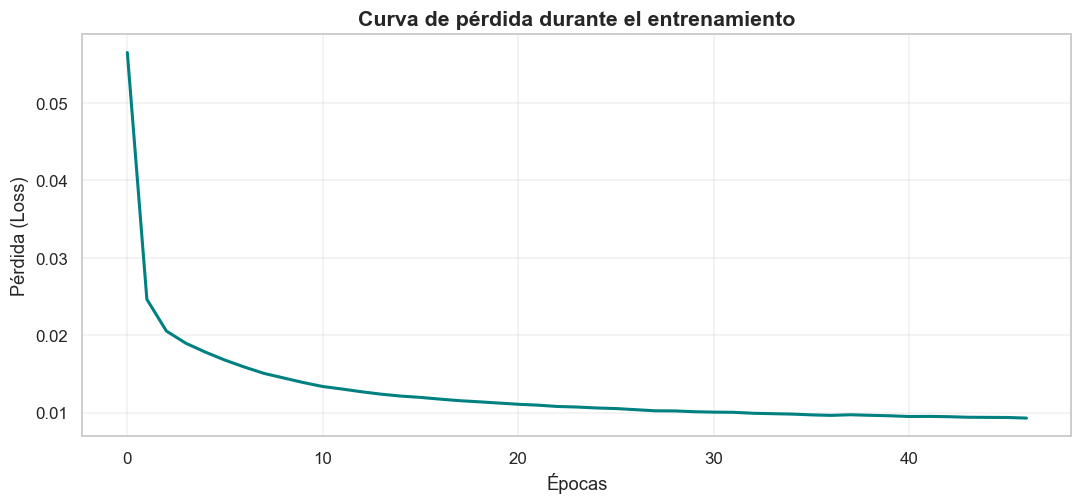

In [32]:
from sklearn.neural_network import MLPRegressor

y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

model = MLPRegressor(
    hidden_layer_sizes=(100,),
    max_iter=2000,
    random_state=42
)

model.fit(X_train_s, y_train)



prediccionmlp=model.predict(X_test_s)

plt.figure(figsize=(10, 5))
plt.plot(model.loss_curve_, linewidth=2, color='teal')
plt.title('Curva de pérdida durante el entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')

plt.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

# print(f'el score del conjunto de datos es : {model.score(X_test_s, y_test)}')


La gráfica indica que el MLP fue reduciendo su pérdida durante el entrenamiento, aprendió rápidamente al principio y después se estabilizó alrededor de 0.01. Esto muestra convergencia del entrenamiento, pero por sí sola no permite concluir si el modelo generaliza bien.

### Evaluación de métricas y análisis del comportamiento de modelos

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import pandas as pd

mae = mean_absolute_error(y_test, prediccionl)
mse = mean_squared_error(y_test, prediccionl)
r2  = r2_score(y_test, prediccionl)
rmse = root_mean_squared_error(y_test, prediccionl)


maer = mean_absolute_error(y_test, prediccionr)
mser = mean_squared_error(y_test, prediccionr)
r2r  = r2_score(y_test, prediccionr)
rmser = root_mean_squared_error(y_test, prediccionr)

maes = mean_absolute_error(y_test, prediccionls)
mses = mean_squared_error(y_test, prediccionls)
r2s = r2_score(y_test, prediccionls)
rmses = root_mean_squared_error(y_test, prediccionls)


maem = mean_absolute_error(y_test, prediccionmlp)
msem = mean_squared_error(y_test, prediccionmlp)
r2m = r2_score(y_test, prediccionmlp)
rmsem = root_mean_squared_error(y_test, prediccionmlp)


maead = mean_absolute_error(y_test, prediccionad)
msead = mean_squared_error(y_test, prediccionad)
r2ad = r2_score(y_test, prediccionad)
rmsead = root_mean_squared_error(y_test, prediccionad)


maep = mean_absolute_error(y_test, prediccionp)
msep = mean_squared_error(y_test, prediccionp)
r2p = r2_score(y_test, prediccionp)
rmsep = root_mean_squared_error(y_test, prediccionp)



resultados = pd.DataFrame({
    'Modelo': ['Lineal', 'Ridge', 'Lasso', 'MLP', 'Decision Tree', 'Polynomial'],
    'MAE': [mae, maer, maes, maem, maead, maep],
    'RMSE': [rmse, rmser, rmses, rmsem, rmsead, rmsep],
    'MSE': [mse, mser, mses, msem, msead, msep],
    'R2': [r2, r2r, r2s, r2m, r2ad, r2p]
    
})

resultados

,Modelo,MAE,RMSE,MSE,R2
0,Lineal,0.165137,0.206849,0.042786,0.390707
1,Ridge,0.165137,0.206848,0.042786,0.390709
2,Lasso,0.201107,0.247160,0.061088,0.130080
3,MLP,0.117594,0.150071,0.022521,0.679288
4,Decision Tree,0.166306,0.209723,0.043984,0.373657
5,Polynomial,0.128157,0.163296,0.026666,0.620273


Al comparar los modelos de regresión, el MLP obtuvo el mejor desempeño, presentando el menor MAE (0.1176), RMSE (0.1501) y MSE (0.0225), además del mayor coeficiente de determinación R² (0.6793). El modelo Polynomial también presentó un buen desempeño, mientras que los modelos Lineal, Ridge y Decision Tree obtuvieron resultados inferiores. El modelo Lasso presentó el menor R² (0.1301) y los mayores errores de la comparación.

# Modelos de clasificación.

### Verificar balanceo de clases

In [34]:
dfc['Class'].value_counts()

Class
0    606
1    606
Name: count, dtype: int64

### Regresión Logística

In [35]:

from sklearn.linear_model import LogisticRegression


X_train, X_test, y_train, y_test = train_test_split(
    Xc,
    yc,
    test_size=0.30,
    random_state=42,
    stratify=yc
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelorlg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelorlg.fit(X_train_scaled, y_train)

score_test = modelorlg.score(X_test_scaled, y_test)


prediccionrlg=modelorlg.predict(X_test_scaled)

from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, prediccionrlg)

print(matriz)


print("Score prueba:", score_test)

score_train = modelorlg.score(X_train_scaled, y_train) #  no deberia ir , no se calcula nioguna metrica con datas de entrtenamiento
print("Score entrenamiento:", score_train)


[[179   3]
 [122  60]]
Score prueba: 0.6565934065934066
Score entrenamiento: 0.6709905660377359


### Arbol de decisión

In [36]:
from sklearn.tree import DecisionTreeClassifier


modelo_arbol = DecisionTreeClassifier(
    random_state=42
)

modelo_arbol.fit(X_train_scaled, y_train)

score_train = modelo_arbol.score(X_train_scaled, y_train)
score_test = modelo_arbol.score(X_test_scaled, y_test)


predicciondtc=modelo_arbol.predict(X_test_scaled)

print("Score entrenamiento:", score_train)
print("Score prueba:", score_test)

Score entrenamiento: 1.0
Score prueba: 0.5467032967032966


### KNN

In [37]:
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_scaled, y_train)

score_train = modelo_knn.score(X_train_scaled, y_train)
score_test = modelo_knn.score(X_test_scaled, y_test)

prediccionknn=modelo_knn.predict(X_test_scaled)


### MLP

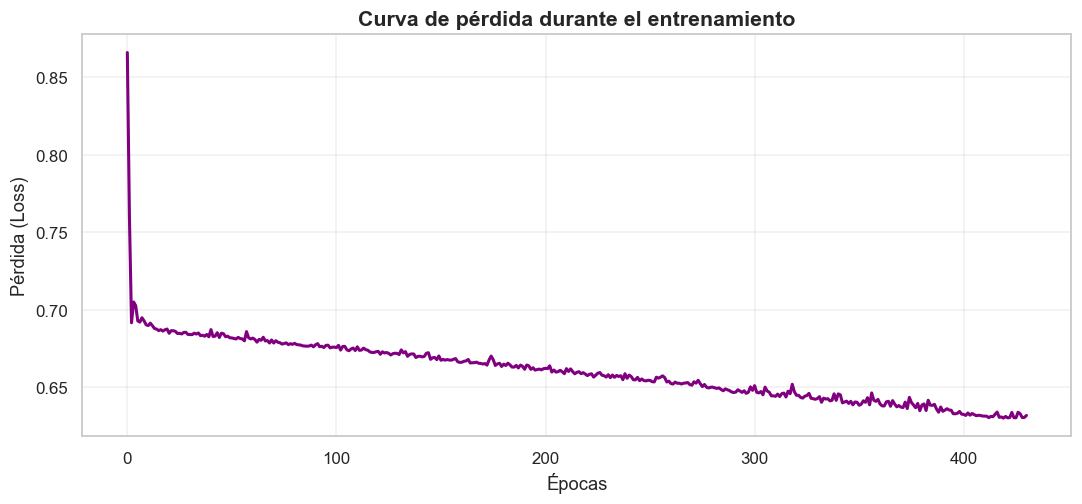

Score entrenamiento: 0.6474056603773585
Score prueba: 0.5851648351648352


In [38]:
from sklearn.neural_network import MLPClassifier

modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=2000,
    random_state=42
)

modelo_mlp.fit(X_train_scaled, y_train)

plt.figure(figsize=(10, 5))
plt.plot(modelo_mlp.loss_curve_, linewidth=2, color='purple')
plt.title('Curva de pérdida durante el entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')

plt.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

score_train = modelo_mlp.score(X_train_scaled, y_train)
score_test = modelo_mlp.score(X_test_scaled, y_test)

prediccionmlpc=modelo_mlp.predict(X_test_scaled)

print("Score entrenamiento:", score_train)
print("Score prueba:", score_test)

El MLP se entrenó durante aproximadamente 430 épocas. La pérdida disminuyó progresivamente desde 0.86 hasta aproximadamente 0.63, mostrando una reducción gradual del error durante el entrenamiento.

### Evaluación de métricas y análisis del comportamiento de modelos

In [39]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

resultados = []

modelos = {
    "Regresión Logística": prediccionrlg,
    "Árbol de Decisión": predicciondtc,
    "KNN": prediccionknn,
    "MLP": prediccionmlpc
}

for nombre, prediccion in modelos.items():

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, prediccion),
        "Precision": precision_score(y_test, prediccion),
        "Recall": recall_score(y_test, prediccion),
        "F1-score": f1_score(y_test, prediccion)
    })

tabla_metricas = pd.DataFrame(resultados)

tabla_metricas

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.656593,0.952381,0.329670,0.489796
1,Árbol de Decisión,0.546703,0.543590,0.582418,0.562334
2,KNN,0.521978,0.519417,0.587912,0.551546
3,MLP,0.585165,0.666667,0.340659,0.450909


En conclusión, el Árbol de Decisión presenta el desempeño más equilibrado entre los modelos evaluados, ya que obtuvo el mayor F1-score (0.562), combinando de manera más balanceada Precision (0.544) y Recall (0.582). Aunque la Regresión Logística obtuvo la mayor Accuracy (0.657) y Precision (0.952), presentó un Recall considerablemente menor (0.330), lo que indica que identificó menos casos positivos


[[ 93  89]
 [ 76 106]]


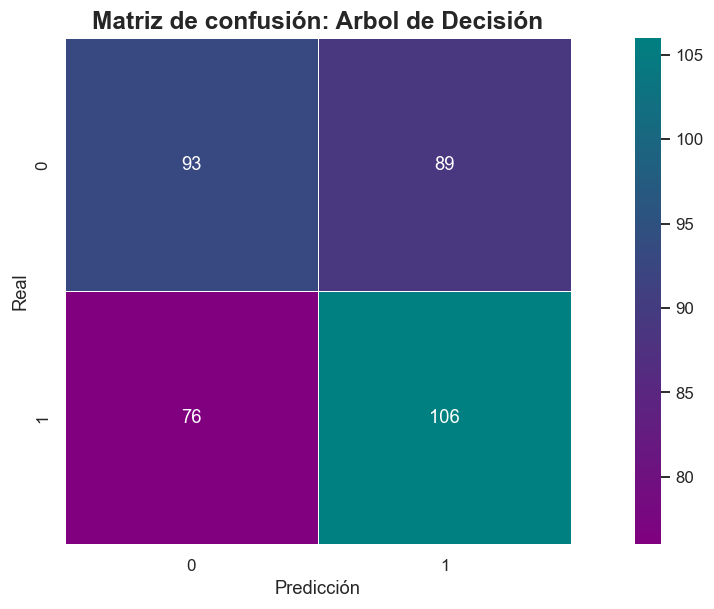

In [40]:
#El mejor modelo

matrix = confusion_matrix(y_test, predicciondtc)

print(matrix)


plt.figure(figsize=(12, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap=cmap_personalizado,
    linewidths=0.5,
    square=True,
    cbar = True
   
    
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión: Arbol de Decisión", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#print("Score entrenamiento:", score_train)
#print("Score prueba:", score_test)

La matriz de confusión muestra que el modelo clasificó correctamente 93 casos de la clase 0 y 106 de la clase 1, mientras que se equivocó en 89 casos de la clase 0 y 76 de la clase 1. En total, obtuvo 199 aciertos de 364 casos, equivalente a una Accuracy aproximada del 54,7%.